<a href="https://colab.research.google.com/github/Akhil-Munjala/objectdetectionendsem/blob/main/object_dectection_endsem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 preprocessing steps:




Text(0.5, 1.0, 'Grayscale')

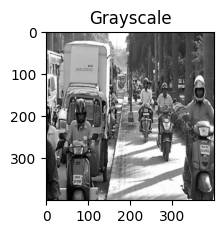

In [5]:
import cv2
import matplotlib.pyplot as plt
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Read image
img = cv2.imread('/content/sample_data/od image.webp')
img = cv2.resize(img, (400, 400))
plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")


Text(0.5, 1.0, 'Gaussian Blur')

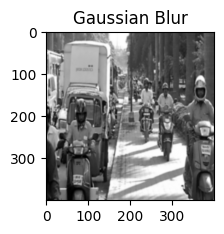

In [6]:
# Noise removal (Gaussian Blur)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
plt.subplot(2,2,3)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")

Text(0.5, 1.0, 'Thresholded')

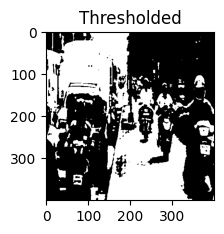

In [7]:
# Thresholding
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)
plt.subplot(2,2,4)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded")

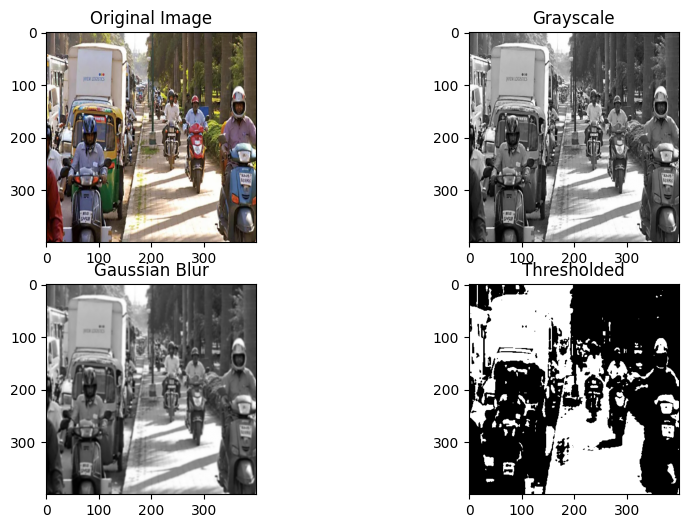

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('/content/sample_data/od image.webp')
img = cv2.resize(img, (400, 400))

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise removal (Gaussian Blur)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Thresholding
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# Display outputs
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(2,2,3)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")

plt.subplot(2,2,4)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded")

plt.show()

2. Extract features


 HOG

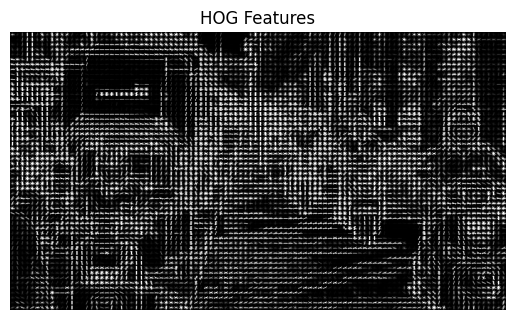

In [8]:
from skimage.feature import hog
from skimage import exposure
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('/content/sample_data/od image.webp')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HOG extraction
features, hog_image = hog(gray, visualize=True)

# Rescale for better visibility
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Display
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Features")
plt.axis('off')
plt.show()

ORB Keypoints (SIFT/SURF Alternative

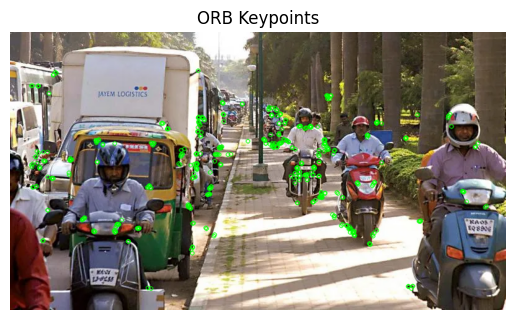

In [9]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('/content/sample_data/od image.webp')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create()

# Detect keypoints
kp, des = orb.detectAndCompute(gray, None)

# Draw keypoints
img_kp = cv2.drawKeypoints(img, kp, None, color=(0,255,0))

# Display
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis('off')
plt.show()

Feature Matching Between Two Images

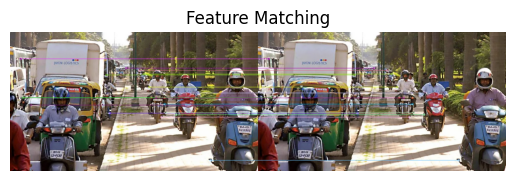

In [10]:
import cv2
import matplotlib.pyplot as plt

# Read two images
img1 = cv2.imread('/content/sample_data/od image.webp')
img2 = cv2.imread('/content/sample_data/od image.webp')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create()

# Detect features
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
match_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=2)

# Display
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis('off')
plt.show()

Part II – Advanced Object Detection (20 Marks)



In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
model = YOLO("yolov8n.pt")

In [14]:
from google.colab import files
uploaded = files.upload()

Saving od image.webp to od image.webp



image 1/1 /content/od image.webp: 384x640 8 persons, 1 car, 5 motorcycles, 5 trucks, 788.4ms
Speed: 15.1ms preprocess, 788.4ms inference, 54.2ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(799.5), np.float64(447.5), np.float64(-0.5))

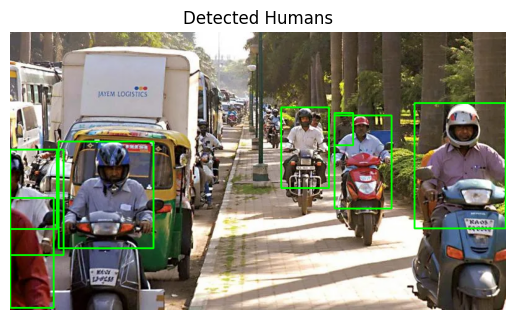

In [15]:
img_path = list(uploaded.keys())[0]

results = model(img_path)

img = cv2.imread(img_path)

for box, cls in zip(results[0].boxes.xyxy, results[0].boxes.cls):
    if int(cls) == 0:  # class 0 = person
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Detected Humans")
plt.axis("off")

In [16]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union != 0 else 0

In [17]:
# Example ground truth (edit based on your image)
ground_truth = [
    [50, 100, 200, 400]  # manually adjust
]

predicted = []

for box, cls in zip(results[0].boxes.xyxy, results[0].boxes.cls):
    if int(cls) == 0:
        predicted.append(list(map(int, box)))

In [12]:
# Example Ground Truth Boxes
ground_truth = [
    [50, 50, 150, 150],
    [30, 30, 100, 100]
]

# Example Predicted Boxes
predicted = [
    [55, 60, 148, 152],
    [10, 10, 40, 40],
    [35, 35, 98, 102]
]

# IoU Function
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = boxAArea + boxBArea - interArea

    return interArea / (union + 1e-6)


# Evaluation Function (Correct Version)
def evaluate_detections(ground_truth, predicted, iou_threshold=0.5):
    TP, FP, FN = 0, 0, 0

    matched_preds = set()

    for gt in ground_truth:
        best_iou = 0
        best_pred_idx = -1

        for i, pred in enumerate(predicted):
            if i in matched_preds:
                continue

            iou = calculate_iou(gt, pred)

            if iou > best_iou:
                best_iou = iou
                best_pred_idx = i

        if best_iou >= iou_threshold:
            TP += 1
            matched_preds.add(best_pred_idx)
        else:
            FN += 1

    FP = len(predicted) - len(matched_preds)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)

    return TP, FP, FN, precision, recall


# Run Evaluation
TP, FP, FN, precision, recall = evaluate_detections(ground_truth, predicted)

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("Precision:", precision)
print("Recall:", recall)

TP: 2
FP: 1
FN: 0
Precision: 0.6666664444445185
Recall: 0.99999950000025


In [6]:
import cv2
from ultralytics import YOLO

# Ensure 'img' is defined by re-reading the image
# The image path is known from previous successful operations
img = cv2.imread('/content/od image.webp')

# Initialize the model if it's not defined
model = YOLO("yolov8n.pt")

dark = cv2.convertScaleAbs(img, alpha=0.4, beta=0)
model(dark, show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 384x640 9 persons, 6 motorcycles, 4 trucks, 185.8ms
Speed: 5.7ms preprocess, 185.8ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
import numpy as np
import cv2

noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
noisy = cv2.add(img, noise)

model(noisy, show=True)

In [3]:
import cv2
from ultralytics import YOLO

# Re-read the image to ensure 'img' is defined
img = cv2.imread('/content/od image.webp')

# Re-initialize the model to ensure 'model' is defined
model = YOLO("yolov8n.pt")

occluded = img.copy()
h, w, _ = img.shape

cv2.rectangle(occluded, (w//4, h//4), (w//2, h//2), (0,0,0), -1)

model(occluded, show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 384x640 10 persons, 5 motorcycles, 3 trucks, 185.1ms
Speed: 10.0ms preprocess, 185.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p